# Classification of HCC samples with Biopsy and Resection samples

#### In this notebook I perform comparison with biopsy/resection samples to the classification data - The input of this analysis is counts data (BvR combined with Class), aligned in SE mode, length 50. 

#### Annotate genes with RNA_biotype and gene name -  Keep only Protein coding genes

####  plot PCA, Clustermap

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import math
import pickle
from pprint import pprint

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import stats

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.pyplot import gcf
from matplotlib import cm, colors

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

sns.set(font_scale=1.5)
sns.set_style("ticks")

In [4]:
# New sample mapping with clinical features
meta = pd.read_csv('../sample_mapping_BvR.csv')
# We only do HCC
meta = meta[meta['Tumor diagnosis'] == 'HCC']
# Only take patients were we have all transcriptome samples
rna_cols = ['Biopsy_tu_transcriptome', 'Resection_tu_transcriptome']
meta = meta.dropna(subset=rna_cols)
meta = meta[(meta['Patient ID'] != 'M') & (meta['Patient ID'] != 'M')]
meta = meta[(meta['Patient ID'] != 'C') & (meta['Patient ID'] != 'C')]
meta.head()

,Patient ID,Biopsy_nt_transcriptome,Biopsy_tu_transcriptome,Resection_nt_transcriptome,Resection_tu_transcriptome,Biopsy_nt_proteome,Biopsy_tu_proteome,Resection_nt_protome,Resection_tu_protome,Biopsy_nt_phospho,Biopsy_tu_phospho,Resection_nt_phospho,Resection_tu_phospho,Age,Sex,PreBx_MELD,PreBx_ALAT,PreBx_ASAT,PreBx_GGT,PreBx_AP,PreBx_Albumin,PreBx_Bilirubin,PreBx_Quick,PreBx_Hb,PreBx_Lc,PreBx_Tc,PreBx_CRP,PreBx_AFP,PreOP_MELD,PreOP_ALAT,PreOP_ASAT,PreOP_GGT,PreOP_AP,PreOP_Albumin,PreOP_Bilirubin,PreOP_Quick,PreOP_Hb,PreOP_Lc,PreOP_Tc,PreOP_CRP,PreOP_AFP,CHILD,BCLC,Nr of nodules,Max nodule size,Time between resection and biopsy,Total surgery time = ischemia time,Tumor diagnosis,Biopsy_nt_hepatocyte,Resection_nt_hepatocyte,Biopsy_nt_stroma,Resection_nt_stroma,Biopsy_tu_tumor,Resection_tu_tumor,Biopsy_tu_stroma,Resection_tu_stroma,Biopsy_tu_necrosis,Resection_tu_necrosis,Biopsy_tu_nontumor,Resection_tu_nontumor
3,B,BSSE_QGF_129466,BSSE_QGF_129467,BSSE_QGF_129468,BSSE_QGF_129469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,M,12.0,53.0,55.0,46.0,137.0,36.0,43.0,72.0,141.0,4.0,54.0,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1,70.0,43.0,NaN,HCC,84.0,94.0,16.0,6.0,86.0,99.0,8.0,0.0,0.0,1.0,5.0,0.0
7,D,BSSE_QGF_182052,BSSE_QGF_182053,BSSE_QGF_182082,BSSE_QGF_182083,011_BR-LF-3_C21,012_BR-LF-3_C21,032_BR-LF-3_C21,033r_BR-LF-3_C21,011_BR-LF-3P_PO4_C21,012_BR-LF-3P_PO4_C21,032_BR-LF-3P_PO4_C21,033_BR-LF-3P_PO4_C21,70.0,F,6.0,29.0,22.0,23.0,82.0,41.0,9.0,94.0,147.0,11.0,254.0,0.3,2.0,6.0,22.0,20.0,22.0,93.0,42.0,11.0,95.0,139.0,11.0,284.0,0.3,NaN,NaN,A,1,23.0,29.0,87.0,HCC,84.0,87.0,16.0,13.0,47.0,97.0,29.0,3.0,0.0,0.0,24.0,0.0
9,E,BSSE_QGF_145476,BSSE_QGF_145477,BSSE_QGF_145478,BSSE_QGF_145479,075_BR-LF-3_C21,076_BR-LF-3_C21,087_BR-LF-3_C21,088_BR-LF-3_C21,075_BR-LF-3P_PO4_C21,076_BR-LF-3P_PO4_C21,087_BR-LF-3P_PO4_C21,088_BR-LF-3P_PO4_C21,79.0,M,6.0,18.0,26.0,167.0,80.0,39.0,10.0,94.0,127.0,5.0,139.0,3.0,12.0,7.0,26.0,28.0,149.0,83.0,38.0,9.0,87.0,139.0,6.0,184.0,2.0,NaN,NaN,A,2,29.0,31.0,149.0,HCC,93.0,90.0,7.0,10.0,61.0,99.0,19.0,1.0,5.0,0.0,15.0,0.0
11,F,BSSE_QGF_145472,BSSE_QGF_145473,BSSE_QGF_145474,BSSE_QGF_145475,077_BR-LF-3_C21,078_BR-LF-3_C21,089_BR-LF-3_C21,090_BR-LF-3_C21,077_BR-LF-3P_PO4_C21,078_BR-LF-3P_PO4_C21,089_BR-LF-3P_PO4_C21,090_BR-LF-3P_PO4_C21,49.0,M,6.0,30.0,29.0,59.0,53.0,38.0,13.0,103.0,161.0,6.0,196.0,1.0,2.0,6.0,25.0,26.0,49.0,56.0,39.0,5.0,115.0,154.0,5.0,209.0,1.0,NaN,NaN,A,1,35.0,11.0,212.0,HCC,99.0,97.0,1.0,3.0,75.0,96.0,10.0,4.0,14.0,0.0,0.0,0.0
15,H,BSSE_QGF_129476,BSSE_QGF_129477,BSSE_QGF_129480,BSSE_QGF_129481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.0,F,11.0,24.0,31.0,23.0,80.0,33.0,25.0,65.0,127.0,4.0,87.0,1.0,NaN,9.0,28.0,35.0,53.0,95.0,36.0,21.0,69.0,117.0,4.0,98.0,NaN,NaN,NaN,A,1,50.0,20.0,64.0,HCC,68.0,82.0,32.0,18.0,98.0,96.0,2.0,4.0,0.0,0.0,0.0,0.0


In [5]:
# Import data

raw_bvr = pd.read_csv('../counts_080725.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw_bvr = raw_bvr.iloc[:,5:]
# Change column names
raw_bvr.columns = raw_bvr.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')

# Check if we have all rna seq samples in the counts table
found = []
for group in rna_cols:
    for seq_id in meta[group]:
        if seq_id in raw_bvr.columns:
            found.append(seq_id)
        else:
            print('missing:', seq_id)
            
# Extras
extras = []
for seq_id in raw_bvr.columns:
    if seq_id in found:
        continue
    else:
        print('extra:', seq_id)
        extras.append(seq_id)
raw_bvr = raw_bvr.drop(extras, axis=1)

raw_bvr.head()

extra: BSSE_QGF_129466
extra: BSSE_QGF_129468
extra: BSSE_QGF_129474
extra: BSSE_QGF_129476
extra: BSSE_QGF_129478
extra: BSSE_QGF_129480
extra: BSSE_QGF_129482
extra: BSSE_QGF_145457
extra: BSSE_QGF_145458
extra: BSSE_QGF_145460
extra: BSSE_QGF_145462
extra: BSSE_QGF_145465
extra: BSSE_QGF_145466
extra: BSSE_QGF_145472
extra: BSSE_QGF_145474
extra: BSSE_QGF_145476
extra: BSSE_QGF_145478
extra: BSSE_QGF_145480
extra: BSSE_QGF_145481
extra: BSSE_QGF_182046
extra: BSSE_QGF_182047
extra: BSSE_QGF_182048
extra: BSSE_QGF_182049
extra: BSSE_QGF_182052
extra: BSSE_QGF_182054
extra: BSSE_QGF_182056
extra: BSSE_QGF_182057
extra: BSSE_QGF_182064
extra: BSSE_QGF_182066
extra: BSSE_QGF_182070
extra: BSSE_QGF_182072
extra: BSSE_QGF_182074
extra: BSSE_QGF_182076
extra: BSSE_QGF_182080
extra: BSSE_QGF_182081
extra: BSSE_QGF_182082
extra: BSSE_QGF_182084
extra: BSSE_QGF_182087
extra: BSSE_QGF_182088
extra: BSSE_QGF_182091
extra: BSSE_QGF_182092
extra: BSSE_QGF_182098
extra: BSSE_QGF_182100
extra: BSSE

,BSSE_QGF_129467,BSSE_QGF_129469,BSSE_QGF_129475,BSSE_QGF_129477,BSSE_QGF_129479,BSSE_QGF_129481,BSSE_QGF_145461,BSSE_QGF_145463,BSSE_QGF_145473,BSSE_QGF_145475,BSSE_QGF_145477,BSSE_QGF_145479,BSSE_QGF_182053,BSSE_QGF_182055,BSSE_QGF_182065,BSSE_QGF_182067,BSSE_QGF_182071,BSSE_QGF_182073,BSSE_QGF_182075,BSSE_QGF_182077,BSSE_QGF_182083,BSSE_QGF_182085,BSSE_QGF_182099,BSSE_QGF_182101,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182107,BSSE_QGF_182111,BSSE_QGF_55730,BSSE_QGF_55744
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,531,307,589,268,243,268,147,179,139,171,578,721,379,399,677,866,340,688,294,325,452,250,272,462,351,231,1579,279,491,217
ENSG00000279928,1,3,1,22,1,32,3,1,0,0,0,3,2,0,0,10,0,0,0,1,0,5,1,3,0,3,2,0,4,1
ENSG00000228037,11,0,13,17,2,9,6,3,6,7,19,20,11,25,10,18,11,8,10,19,18,24,7,16,7,2,43,3,16,12
ENSG00000142611,9,5,20,66,10,71,6,2,7,4,6,11,5,24,50,247,49,17,14,5,9,9,3,73,80,79,6,5,73,66
ENSG00000284616,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6


In [6]:
# Import data

raw_class = pd.read_csv('../counts_with_class.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw_class = raw_class.iloc[:,5:]
# Change column names
raw_class.columns = raw_class.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')
raw_class.head()

,BSSE_QGF_107014,BSSE_QGF_107024,BSSE_QGF_107028,BSSE_QGF_107037,BSSE_QGF_107047,BSSE_QGF_107058,BSSE_QGF_107063,BSSE_QGF_34365,BSSE_QGF_34369,BSSE_QGF_34371,BSSE_QGF_34375,BSSE_QGF_34377,BSSE_QGF_34379,BSSE_QGF_34381,BSSE_QGF_34383,BSSE_QGF_34385,BSSE_QGF_34387,BSSE_QGF_34389,BSSE_QGF_34391,BSSE_QGF_34393,BSSE_QGF_34394,BSSE_QGF_34398,BSSE_QGF_34400,BSSE_QGF_34404,BSSE_QGF_34406,BSSE_QGF_34408,BSSE_QGF_34410,BSSE_QGF_34412,BSSE_QGF_34414,BSSE_QGF_34416,BSSE_QGF_34420,BSSE_QGF_34424,BSSE_QGF_34426,BSSE_QGF_34427,BSSE_QGF_34431,BSSE_QGF_34433,BSSE_QGF_34435,BSSE_QGF_34437,BSSE_QGF_34439,BSSE_QGF_34441,BSSE_QGF_34443,BSSE_QGF_34445,BSSE_QGF_34447,BSSE_QGF_34449,BSSE_QGF_34451,BSSE_QGF_34453,BSSE_QGF_34455,BSSE_QGF_34457,BSSE_QGF_34459,BSSE_QGF_34463,BSSE_QGF_34465,BSSE_QGF_34467,BSSE_QGF_34469,BSSE_QGF_34480,BSSE_QGF_34484,BSSE_QGF_34486,BSSE_QGF_34495,BSSE_QGF_35690,BSSE_QGF_35698,BSSE_QGF_35706,BSSE_QGF_54955,BSSE_QGF_54957,BSSE_QGF_54961,BSSE_QGF_54963,BSSE_QGF_54967,BSSE_QGF_54968,BSSE_QGF_54969,BSSE_QGF_54973,BSSE_QGF_54975,BSSE_QGF_54979,BSSE_QGF_54980,BSSE_QGF_54984,BSSE_QGF_54992,BSSE_QGF_54994,BSSE_QGF_54997,BSSE_QGF_54999,BSSE_QGF_55004,BSSE_QGF_55006,BSSE_QGF_55012,BSSE_QGF_55017,BSSE_QGF_55019,BSSE_QGF_55024,BSSE_QGF_55026,BSSE_QGF_55028,BSSE_QGF_55034,BSSE_QGF_55040,BSSE_QGF_55042,BSSE_QGF_55044,BSSE_QGF_55698,BSSE_QGF_55704,BSSE_QGF_55706,BSSE_QGF_55708,BSSE_QGF_55712,BSSE_QGF_55719,BSSE_QGF_55721,BSSE_QGF_55725,BSSE_QGF_55727,BSSE_QGF_55729,BSSE_QGF_55735,BSSE_QGF_55737,BSSE_QGF_55739,BSSE_QGF_55747,BSSE_QGF_55751,BSSE_QGF_55756,BSSE_QGF_55761,BSSE_QGF_55763,BSSE_QGF_55774,BSSE_QGF_79904,BSSE_QGF_79908,GFB_37105,GFB_37107,GFB_37108,GFB_37111,GFB_37113,GFB_37117
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,989,301,895,316,275,1344,279,97,458,794,128,424,365,410,786,497,589,358,527,486,963,521,580,3576,212,950,273,177,275,434,396,714,319,231,254,88,656,331,276,280,418,162,291,1022,249,479,519,159,559,431,110,1266,368,393,508,703,398,442,69,2239,156,382,293,94,441,385,2277,1841,327,173,207,266,306,308,319,264,1484,187,119,1594,233,243,470,238,335,149,115,214,169,266,723,317,279,535,368,489,142,739,130,221,201,93,408,237,376,221,165,3398,798,241,1816,1832,570,2825,1458
ENSG00000279928,2,3,1,0,3,3,0,0,3,0,1,4,1,0,1,2,2,0,1,1,1,1,0,4,1,0,1,0,3,1,2,1,2,3,0,3,2,3,1,1,3,1,3,7,8,3,1,0,1,3,0,0,0,3,3,0,2,1,2,1,0,0,1,0,4,3,7,8,0,3,2,0,0,0,1,5,1,5,0,4,3,0,0,3,1,0,2,0,1,4,0,0,1,2,3,2,3,2,0,3,0,0,1,2,4,3,9,2,6,3,6,0,15,1,6
ENSG00000228037,13,16,27,27,13,35,11,1,7,9,10,8,8,14,3,13,18,10,9,8,6,13,7,18,10,10,18,3,13,12,14,23,6,8,7,10,4,10,9,22,8,1,20,27,21,8,23,3,13,19,10,17,15,12,12,9,15,1,6,12,15,47,7,10,81,13,25,54,5,20,12,22,19,7,6,12,3,14,7,35,8,16,16,11,12,20,26,18,39,27,26,8,18,35,25,21,14,27,10,15,9,3,8,5,7,8,10,15,22,5,31,14,21,48,54
ENSG00000142611,4,3,674,11,191,7,92,2,20,30,3,97,19,13,3,22,21,5,9,2,11,4,17,50,9,3,13,2,19,49,30,3,5,18,5,30,7,18,4,2,53,8,30,16,21,19,3,2,47,35,1,50,28,28,44,18,15,22,4,7,4,40,5,10,41,14,16,21,21,13,24,1,192,68,55,3,314,0,4,0,5,2,22,3,3,4,5,14,5,8,4,24,3,7,1,15,16,58,8,3,7,4,3,14,2,1,0,3,14,0,12,53,31,302,1187
ENSG00000284616,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:
# combine counts tables

raw = pd.concat([raw_bvr, raw_class], axis=1)
raw.head()

,BSSE_QGF_129467,BSSE_QGF_129469,BSSE_QGF_129475,BSSE_QGF_129477,BSSE_QGF_129479,BSSE_QGF_129481,BSSE_QGF_145461,BSSE_QGF_145463,BSSE_QGF_145473,BSSE_QGF_145475,BSSE_QGF_145477,BSSE_QGF_145479,BSSE_QGF_182053,BSSE_QGF_182055,BSSE_QGF_182065,BSSE_QGF_182067,BSSE_QGF_182071,BSSE_QGF_182073,BSSE_QGF_182075,BSSE_QGF_182077,BSSE_QGF_182083,BSSE_QGF_182085,BSSE_QGF_182099,BSSE_QGF_182101,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182107,BSSE_QGF_182111,BSSE_QGF_55730,BSSE_QGF_55744,BSSE_QGF_107014,BSSE_QGF_107024,BSSE_QGF_107028,BSSE_QGF_107037,BSSE_QGF_107047,BSSE_QGF_107058,BSSE_QGF_107063,BSSE_QGF_34365,BSSE_QGF_34369,BSSE_QGF_34371,BSSE_QGF_34375,BSSE_QGF_34377,BSSE_QGF_34379,BSSE_QGF_34381,BSSE_QGF_34383,BSSE_QGF_34385,BSSE_QGF_34387,BSSE_QGF_34389,BSSE_QGF_34391,BSSE_QGF_34393,BSSE_QGF_34394,BSSE_QGF_34398,BSSE_QGF_34400,BSSE_QGF_34404,BSSE_QGF_34406,BSSE_QGF_34408,BSSE_QGF_34410,BSSE_QGF_34412,BSSE_QGF_34414,BSSE_QGF_34416,BSSE_QGF_34420,BSSE_QGF_34424,BSSE_QGF_34426,BSSE_QGF_34427,BSSE_QGF_34431,BSSE_QGF_34433,BSSE_QGF_34435,BSSE_QGF_34437,BSSE_QGF_34439,BSSE_QGF_34441,BSSE_QGF_34443,BSSE_QGF_34445,BSSE_QGF_34447,BSSE_QGF_34449,BSSE_QGF_34451,BSSE_QGF_34453,BSSE_QGF_34455,BSSE_QGF_34457,BSSE_QGF_34459,BSSE_QGF_34463,BSSE_QGF_34465,BSSE_QGF_34467,BSSE_QGF_34469,BSSE_QGF_34480,BSSE_QGF_34484,BSSE_QGF_34486,BSSE_QGF_34495,BSSE_QGF_35690,BSSE_QGF_35698,BSSE_QGF_35706,BSSE_QGF_54955,BSSE_QGF_54957,BSSE_QGF_54961,BSSE_QGF_54963,BSSE_QGF_54967,BSSE_QGF_54968,BSSE_QGF_54969,BSSE_QGF_54973,BSSE_QGF_54975,BSSE_QGF_54979,BSSE_QGF_54980,BSSE_QGF_54984,BSSE_QGF_54992,BSSE_QGF_54994,BSSE_QGF_54997,BSSE_QGF_54999,BSSE_QGF_55004,BSSE_QGF_55006,BSSE_QGF_55012,BSSE_QGF_55017,BSSE_QGF_55019,BSSE_QGF_55024,BSSE_QGF_55026,BSSE_QGF_55028,BSSE_QGF_55034,BSSE_QGF_55040,BSSE_QGF_55042,BSSE_QGF_55044,BSSE_QGF_55698,BSSE_QGF_55704,BSSE_QGF_55706,BSSE_QGF_55708,BSSE_QGF_55712,BSSE_QGF_55719,BSSE_QGF_55721,BSSE_QGF_55725,BSSE_QGF_55727,BSSE_QGF_55729,BSSE_QGF_55735,BSSE_QGF_55737,BSSE_QGF_55739,BSSE_QGF_55747,BSSE_QGF_55751,BSSE_QGF_55756,BSSE_QGF_55761,BSSE_QGF_55763,BSSE_QGF_55774,BSSE_QGF_79904,BSSE_QGF_79908,GFB_37105,GFB_37107,GFB_37108,GFB_37111,GFB_37113,GFB_37117
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,531,307,589,268,243,268,147,179,139,171,578,721,379,399,677,866,340,688,294,325,452,250,272,462,351,231,1579,279,491,217,989,301,895,316,275,1344,279,97,458,794,128,424,365,410,786,497,589,358,527,486,963,521,580,3576,212,950,273,177,275,434,396,714,319,231,254,88,656,331,276,280,418,162,291,1022,249,479,519,159,559,431,110,1266,368,393,508,703,398,442,69,2239,156,382,293,94,441,385,2277,1841,327,173,207,266,306,308,319,264,1484,187,119,1594,233,243,470,238,335,149,115,214,169,266,723,317,279,535,368,489,142,739,130,221,201,93,408,237,376,221,165,3398,798,241,1816,1832,570,2825,1458
ENSG00000279928,1,3,1,22,1,32,3,1,0,0,0,3,2,0,0,10,0,0,0,1,0,5,1,3,0,3,2,0,4,1,2,3,1,0,3,3,0,0,3,0,1,4,1,0,1,2,2,0,1,1,1,1,0,4,1,0,1,0,3,1,2,1,2,3,0,3,2,3,1,1,3,1,3,7,8,3,1,0,1,3,0,0,0,3,3,0,2,1,2,1,0,0,1,0,4,3,7,8,0,3,2,0,0,0,1,5,1,5,0,4,3,0,0,3,1,0,2,0,1,4,0,0,1,2,3,2,3,2,0,3,0,0,1,2,4,3,9,2,6,3,6,0,15,1,6
ENSG00000228037,11,0,13,17,2,9,6,3,6,7,19,20,11,25,10,18,11,8,10,19,18,24,7,16,7,2,43,3,16,12,13,16,27,27,13,35,11,1,7,9,10,8,8,14,3,13,18,10,9,8,6,13,7,18,10,10,18,3,13,12,14,23,6,8,7,10,4,10,9,22,8,1,20,27,21,8,23,3,13,19,10,17,15,12,12,9,15,1,6,12,15,47,7,10,81,13,25,54,5,20,12,22,19,7,6,12,3,14,7,35,8,16,16,11,12,20,26,18,39,27,26,8,18,35,25,21,14,27,10,15,9,3,8,5,7,8,10,15,22,5,31,14,21,48,54
ENSG00000142611,9,5,20,66,10,71,6,2,7,4,6,11,5,24,50,247,49,17,14,5,9,9,3,73,80,79,6,5,73,66,4,3,674,11,191,7,92,2,20,30,3,97,19,13,3,22,21,5,9,2,11,4,17,50,9,3,13,2,19,49,30,3,5,18,5,30,7,18,4,2,53,8,30,16,21,19,3,2,47,35,1,50,28,28,44,18,15,22,4,7,4,40,5,10,41,14,16,21,21,13,24,1,192,68,55,3,314,0,4,0,5,2,22,3,3,4,5,14,5,8,4,24,3,7,1,15,16,58,8,3

In [8]:
raw_bvr.shape

(62703, 30)

In [9]:
raw_class.shape

(62703, 115)

In [10]:
raw.shape

(62703, 145)

In [11]:
# Add Gene Biotype Names
with open('../../../ensemble_mappings_biotype.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_bt = raw.reset_index(names='Geneid').copy()
    
df_bt['Biotype'] = df_bt['Geneid'].map(loaded_dict)
df_bt.Biotype = df_bt.Biotype.replace('', np.nan)
df_bt.index = df_bt.Geneid
df_bt = df_bt.drop('Geneid', axis=1)

In [12]:
# Take only protein coding genes
df_pc = df_bt[df_bt.Biotype == 'protein_coding'].copy()
df_pc = df_pc.drop('Biotype', axis=1)
df_pc.index.name = None
df_pc.shape

(20056, 145)

In [13]:
# Create metadata for Deseq
meta_rna = meta.loc[:,['Patient ID', 'Biopsy_tu_transcriptome',
                       'Resection_tu_transcriptome','Age', 'Sex']].copy()
meta_rna = meta_rna.melt(id_vars=['Patient ID', 'Age', 'Sex'],
                         value_vars=['Biopsy_tu_transcriptome',
                                     'Resection_tu_transcriptome',])
meta_rna['Sample_type'] = meta_rna.variable.str.split('_').str[0]
meta_rna = meta_rna.drop('variable', axis=1)
meta_rna = meta_rna.rename({'value':'Seq_id'}, axis=1)
meta_rna.head()

,Patient ID,Age,Sex,Seq_id,Sample_type
0,B,59.0,M,BSSE_QGF_129467,Biopsy
1,D,70.0,F,BSSE_QGF_182053,Biopsy
2,E,79.0,M,BSSE_QGF_145477,Biopsy
3,F,49.0,M,BSSE_QGF_145473,Biopsy
4,H,69.0,F,BSSE_QGF_129477,Biopsy


In [14]:
raw_class.columns

Index(['BSSE_QGF_107014', 'BSSE_QGF_107024', 'BSSE_QGF_107028',
       'BSSE_QGF_107037', 'BSSE_QGF_107047', 'BSSE_QGF_107058',
       'BSSE_QGF_107063', 'BSSE_QGF_34365', 'BSSE_QGF_34369', 'BSSE_QGF_34371',
       ...
       'BSSE_QGF_55763', 'BSSE_QGF_55774', 'BSSE_QGF_79904', 'BSSE_QGF_79908',
       'GFB_37105', 'GFB_37107', 'GFB_37108', 'GFB_37111', 'GFB_37113',
       'GFB_37117'],
      dtype='object', length=115)

In [15]:
metadata = meta_rna.copy()
metadata.index = metadata.Seq_id

metadata = pd.concat([metadata, pd.DataFrame(raw_class.columns, columns=['Seq_id'])])
metadata.Sample_type = metadata.Sample_type.fillna('Class')
metadata.tail()

,Patient ID,Age,Sex,Seq_id,Sample_type
110,NaN,NaN,NaN,GFB_37107,Class
111,NaN,NaN,NaN,GFB_37108,Class
112,NaN,NaN,NaN,GFB_37111,Class
113,NaN,NaN,NaN,GFB_37113,Class
114,NaN,NaN,NaN,GFB_37117,Class


In [16]:
df_pc.columns

Index(['BSSE_QGF_129467', 'BSSE_QGF_129469', 'BSSE_QGF_129475',
       'BSSE_QGF_129477', 'BSSE_QGF_129479', 'BSSE_QGF_129481',
       'BSSE_QGF_145461', 'BSSE_QGF_145463', 'BSSE_QGF_145473',
       'BSSE_QGF_145475',
       ...
       'BSSE_QGF_55763', 'BSSE_QGF_55774', 'BSSE_QGF_79904', 'BSSE_QGF_79908',
       'GFB_37105', 'GFB_37107', 'GFB_37108', 'GFB_37111', 'GFB_37113',
       'GFB_37117'],
      dtype='object', length=145)

In [17]:
# Filtering

# Create a copy to work on
df_pc_ = df_pc.copy()

# Apply the filter criteria
for col in df_pc_.columns:
    df_pc_[col] = np.where(df_pc_[col] >= 10, True, False)

# Determine which rows have at least `min_trues` True values
df_pc_['Keep'] = np.where(df_pc_.sum(axis=1) >= 3, True, False)

# Store the indices of the rows to keep
keep_indices_ = df_pc_[df_pc_.Keep].index

# Return only the rows that were determined to be kept during fitting
df_pc_ = df_pc.loc[keep_indices_].copy()

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_4452\562405431.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pc_['Keep'] = np.where(df_pc_.sum(axis=1) >= 3, True, False)


In [18]:
df_pc_.columns

Index(['BSSE_QGF_129467', 'BSSE_QGF_129469', 'BSSE_QGF_129475',
       'BSSE_QGF_129477', 'BSSE_QGF_129479', 'BSSE_QGF_129481',
       'BSSE_QGF_145461', 'BSSE_QGF_145463', 'BSSE_QGF_145473',
       'BSSE_QGF_145475',
       ...
       'BSSE_QGF_55763', 'BSSE_QGF_55774', 'BSSE_QGF_79904', 'BSSE_QGF_79908',
       'GFB_37105', 'GFB_37107', 'GFB_37108', 'GFB_37111', 'GFB_37113',
       'GFB_37117'],
      dtype='object', length=145)

In [19]:
metadata.head()

,Patient ID,Age,Sex,Seq_id,Sample_type
BSSE_QGF_129467,B,59.0,M,BSSE_QGF_129467,Biopsy
BSSE_QGF_182053,D,70.0,F,BSSE_QGF_182053,Biopsy
BSSE_QGF_145477,E,79.0,M,BSSE_QGF_145477,Biopsy
BSSE_QGF_145473,F,49.0,M,BSSE_QGF_145473,Biopsy
BSSE_QGF_129477,H,69.0,F,BSSE_QGF_129477,Biopsy


In [20]:
# Same sorting
metadata = metadata.sort_values('Seq_id')
metadata.index = metadata.Seq_id
metadata.head()

,Patient ID,Age,Sex,Seq_id,Sample_type
Seq_id,,,,,
BSSE_QGF_107014,NaN,NaN,NaN,BSSE_QGF_107014,Class
BSSE_QGF_107024,NaN,NaN,NaN,BSSE_QGF_107024,Class
BSSE_QGF_107028,NaN,NaN,NaN,BSSE_QGF_107028,Class
BSSE_QGF_107037,NaN,NaN,NaN,BSSE_QGF_107037,Class
BSSE_QGF_107047,NaN,NaN,NaN,BSSE_QGF_107047,Class


In [21]:
df_pc.head()

,BSSE_QGF_129467,BSSE_QGF_129469,BSSE_QGF_129475,BSSE_QGF_129477,BSSE_QGF_129479,BSSE_QGF_129481,BSSE_QGF_145461,BSSE_QGF_145463,BSSE_QGF_145473,BSSE_QGF_145475,BSSE_QGF_145477,BSSE_QGF_145479,BSSE_QGF_182053,BSSE_QGF_182055,BSSE_QGF_182065,BSSE_QGF_182067,BSSE_QGF_182071,BSSE_QGF_182073,BSSE_QGF_182075,BSSE_QGF_182077,BSSE_QGF_182083,BSSE_QGF_182085,BSSE_QGF_182099,BSSE_QGF_182101,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182107,BSSE_QGF_182111,BSSE_QGF_55730,BSSE_QGF_55744,BSSE_QGF_107014,BSSE_QGF_107024,BSSE_QGF_107028,BSSE_QGF_107037,BSSE_QGF_107047,BSSE_QGF_107058,BSSE_QGF_107063,BSSE_QGF_34365,BSSE_QGF_34369,BSSE_QGF_34371,BSSE_QGF_34375,BSSE_QGF_34377,BSSE_QGF_34379,BSSE_QGF_34381,BSSE_QGF_34383,BSSE_QGF_34385,BSSE_QGF_34387,BSSE_QGF_34389,BSSE_QGF_34391,BSSE_QGF_34393,BSSE_QGF_34394,BSSE_QGF_34398,BSSE_QGF_34400,BSSE_QGF_34404,BSSE_QGF_34406,BSSE_QGF_34408,BSSE_QGF_34410,BSSE_QGF_34412,BSSE_QGF_34414,BSSE_QGF_34416,BSSE_QGF_34420,BSSE_QGF_34424,BSSE_QGF_34426,BSSE_QGF_34427,BSSE_QGF_34431,BSSE_QGF_34433,BSSE_QGF_34435,BSSE_QGF_34437,BSSE_QGF_34439,BSSE_QGF_34441,BSSE_QGF_34443,BSSE_QGF_34445,BSSE_QGF_34447,BSSE_QGF_34449,BSSE_QGF_34451,BSSE_QGF_34453,BSSE_QGF_34455,BSSE_QGF_34457,BSSE_QGF_34459,BSSE_QGF_34463,BSSE_QGF_34465,BSSE_QGF_34467,BSSE_QGF_34469,BSSE_QGF_34480,BSSE_QGF_34484,BSSE_QGF_34486,BSSE_QGF_34495,BSSE_QGF_35690,BSSE_QGF_35698,BSSE_QGF_35706,BSSE_QGF_54955,BSSE_QGF_54957,BSSE_QGF_54961,BSSE_QGF_54963,BSSE_QGF_54967,BSSE_QGF_54968,BSSE_QGF_54969,BSSE_QGF_54973,BSSE_QGF_54975,BSSE_QGF_54979,BSSE_QGF_54980,BSSE_QGF_54984,BSSE_QGF_54992,BSSE_QGF_54994,BSSE_QGF_54997,BSSE_QGF_54999,BSSE_QGF_55004,BSSE_QGF_55006,BSSE_QGF_55012,BSSE_QGF_55017,BSSE_QGF_55019,BSSE_QGF_55024,BSSE_QGF_55026,BSSE_QGF_55028,BSSE_QGF_55034,BSSE_QGF_55040,BSSE_QGF_55042,BSSE_QGF_55044,BSSE_QGF_55698,BSSE_QGF_55704,BSSE_QGF_55706,BSSE_QGF_55708,BSSE_QGF_55712,BSSE_QGF_55719,BSSE_QGF_55721,BSSE_QGF_55725,BSSE_QGF_55727,BSSE_QGF_55729,BSSE_QGF_55735,BSSE_QGF_55737,BSSE_QGF_55739,BSSE_QGF_55747,BSSE_QGF_55751,BSSE_QGF_55756,BSSE_QGF_55761,BSSE_QGF_55763,BSSE_QGF_55774,BSSE_QGF_79904,BSSE_QGF_79908,GFB_37105,GFB_37107,GFB_37108,GFB_37111,GFB_37113,GFB_37117
ENSG00000160072,531,307,589,268,243,268,147,179,139,171,578,721,379,399,677,866,340,688,294,325,452,250,272,462,351,231,1579,279,491,217,989,301,895,316,275,1344,279,97,458,794,128,424,365,410,786,497,589,358,527,486,963,521,580,3576,212,950,273,177,275,434,396,714,319,231,254,88,656,331,276,280,418,162,291,1022,249,479,519,159,559,431,110,1266,368,393,508,703,398,442,69,2239,156,382,293,94,441,385,2277,1841,327,173,207,266,306,308,319,264,1484,187,119,1594,233,243,470,238,335,149,115,214,169,266,723,317,279,535,368,489,142,739,130,221,201,93,408,237,376,221,165,3398,798,241,1816,1832,570,2825,1458
ENSG00000142611,9,5,20,66,10,71,6,2,7,4,6,11,5,24,50,247,49,17,14,5,9,9,3,73,80,79,6,5,73,66,4,3,674,11,191,7,92,2,20,30,3,97,19,13,3,22,21,5,9,2,11,4,17,50,9,3,13,2,19,49,30,3,5,18,5,30,7,18,4,2,53,8,30,16,21,19,3,2,47,35,1,50,28,28,44,18,15,22,4,7,4,40,5,10,41,14,16,21,21,13,24,1,192,68,55,3,314,0,4,0,5,2,22,3,3,4,5,14,5,8,4,24,3,7,1,15,16,58,8,3,7,4,3,14,2,1,0,3,14,0,12,53,31,302,1187
ENSG00000157911,449,372,472,129,236,168,137,102,263,231,215,182,296,223,362,470,182,184,420,320,293,155,192,248,92,391,275,102,214,90,373,292,575,184,167,907,334,52,364,513,157,254,104,403,198,425,314,561,301,398,623,405,409,529,160,480,225,263,211,440,894,355,452,207,247,186,648,222,190,296,421,262,383,511,254,290,389,222,295,199,79,379,463,320,368,515,345,450,135,219,72,200,120,70,134,178,856,340,296,152,113,204,150,163,259,155,295,103,116,363,216,284,324,131,134,75,120,150,87,161,258,326,144,231,149,192,98,310,117,114,125,73,81,87,137,109,75,680,505,397,941,990,492,520,830
ENSG00000142655,193,160,797,273,471,197,361,322,491,467,326,321,509,354,495,545,296,470,303,146,568,407,359,151,135,548,720,72,258,162,523,252,528,381,53,313,813,68,458,454,165,271,109,382,291,484,231,522,342,473,498,558,245,442,253,562,18

In [22]:
df_pc_ = df_pc_.loc[:,metadata.Seq_id]
df_pc_.head()

,BSSE_QGF_107014,BSSE_QGF_107024,BSSE_QGF_107028,BSSE_QGF_107037,BSSE_QGF_107047,BSSE_QGF_107058,BSSE_QGF_107063,BSSE_QGF_129467,BSSE_QGF_129469,BSSE_QGF_129475,BSSE_QGF_129477,BSSE_QGF_129479,BSSE_QGF_129481,BSSE_QGF_145461,BSSE_QGF_145463,BSSE_QGF_145473,BSSE_QGF_145475,BSSE_QGF_145477,BSSE_QGF_145479,BSSE_QGF_182053,BSSE_QGF_182055,BSSE_QGF_182065,BSSE_QGF_182067,BSSE_QGF_182071,BSSE_QGF_182073,BSSE_QGF_182075,BSSE_QGF_182077,BSSE_QGF_182083,BSSE_QGF_182085,BSSE_QGF_182099,BSSE_QGF_182101,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182107,BSSE_QGF_182111,BSSE_QGF_34365,BSSE_QGF_34369,BSSE_QGF_34371,BSSE_QGF_34375,BSSE_QGF_34377,BSSE_QGF_34379,BSSE_QGF_34381,BSSE_QGF_34383,BSSE_QGF_34385,BSSE_QGF_34387,BSSE_QGF_34389,BSSE_QGF_34391,BSSE_QGF_34393,BSSE_QGF_34394,BSSE_QGF_34398,BSSE_QGF_34400,BSSE_QGF_34404,BSSE_QGF_34406,BSSE_QGF_34408,BSSE_QGF_34410,BSSE_QGF_34412,BSSE_QGF_34414,BSSE_QGF_34416,BSSE_QGF_34420,BSSE_QGF_34424,BSSE_QGF_34426,BSSE_QGF_34427,BSSE_QGF_34431,BSSE_QGF_34433,BSSE_QGF_34435,BSSE_QGF_34437,BSSE_QGF_34439,BSSE_QGF_34441,BSSE_QGF_34443,BSSE_QGF_34445,BSSE_QGF_34447,BSSE_QGF_34449,BSSE_QGF_34451,BSSE_QGF_34453,BSSE_QGF_34455,BSSE_QGF_34457,BSSE_QGF_34459,BSSE_QGF_34463,BSSE_QGF_34465,BSSE_QGF_34467,BSSE_QGF_34469,BSSE_QGF_34480,BSSE_QGF_34484,BSSE_QGF_34486,BSSE_QGF_34495,BSSE_QGF_35690,BSSE_QGF_35698,BSSE_QGF_35706,BSSE_QGF_54955,BSSE_QGF_54957,BSSE_QGF_54961,BSSE_QGF_54963,BSSE_QGF_54967,BSSE_QGF_54968,BSSE_QGF_54969,BSSE_QGF_54973,BSSE_QGF_54975,BSSE_QGF_54979,BSSE_QGF_54980,BSSE_QGF_54984,BSSE_QGF_54992,BSSE_QGF_54994,BSSE_QGF_54997,BSSE_QGF_54999,BSSE_QGF_55004,BSSE_QGF_55006,BSSE_QGF_55012,BSSE_QGF_55017,BSSE_QGF_55019,BSSE_QGF_55024,BSSE_QGF_55026,BSSE_QGF_55028,BSSE_QGF_55034,BSSE_QGF_55040,BSSE_QGF_55042,BSSE_QGF_55044,BSSE_QGF_55698,BSSE_QGF_55704,BSSE_QGF_55706,BSSE_QGF_55708,BSSE_QGF_55712,BSSE_QGF_55719,BSSE_QGF_55721,BSSE_QGF_55725,BSSE_QGF_55727,BSSE_QGF_55729,BSSE_QGF_55730,BSSE_QGF_55735,BSSE_QGF_55737,BSSE_QGF_55739,BSSE_QGF_55744,BSSE_QGF_55747,BSSE_QGF_55751,BSSE_QGF_55756,BSSE_QGF_55761,BSSE_QGF_55763,BSSE_QGF_55774,BSSE_QGF_79904,BSSE_QGF_79908,GFB_37105,GFB_37107,GFB_37108,GFB_37111,GFB_37113,GFB_37117
ENSG00000160072,989,301,895,316,275,1344,279,531,307,589,268,243,268,147,179,139,171,578,721,379,399,677,866,340,688,294,325,452,250,272,462,351,231,1579,279,97,458,794,128,424,365,410,786,497,589,358,527,486,963,521,580,3576,212,950,273,177,275,434,396,714,319,231,254,88,656,331,276,280,418,162,291,1022,249,479,519,159,559,431,110,1266,368,393,508,703,398,442,69,2239,156,382,293,94,441,385,2277,1841,327,173,207,266,306,308,319,264,1484,187,119,1594,233,243,470,238,335,149,115,214,169,266,723,317,279,535,368,489,142,739,491,130,221,201,217,93,408,237,376,221,165,3398,798,241,1816,1832,570,2825,1458
ENSG00000142611,4,3,674,11,191,7,92,9,5,20,66,10,71,6,2,7,4,6,11,5,24,50,247,49,17,14,5,9,9,3,73,80,79,6,5,2,20,30,3,97,19,13,3,22,21,5,9,2,11,4,17,50,9,3,13,2,19,49,30,3,5,18,5,30,7,18,4,2,53,8,30,16,21,19,3,2,47,35,1,50,28,28,44,18,15,22,4,7,4,40,5,10,41,14,16,21,21,13,24,1,192,68,55,3,314,0,4,0,5,2,22,3,3,4,5,14,5,8,4,24,3,7,1,15,16,58,73,8,3,7,66,4,3,14,2,1,0,3,14,0,12,53,31,302,1187
ENSG00000157911,373,292,575,184,167,907,334,449,372,472,129,236,168,137,102,263,231,215,182,296,223,362,470,182,184,420,320,293,155,192,248,92,391,275,102,52,364,513,157,254,104,403,198,425,314,561,301,398,623,405,409,529,160,480,225,263,211,440,894,355,452,207,247,186,648,222,190,296,421,262,383,511,254,290,389,222,295,199,79,379,463,320,368,515,345,450,135,219,72,200,120,70,134,178,856,340,296,152,113,204,150,163,259,155,295,103,116,363,216,284,324,131,134,75,120,150,87,161,258,326,144,231,149,192,98,310,214,117,114,125,90,73,81,87,137,109,75,680,505,397,941,990,492,520,830
ENSG00000142655,523,252,528,381,53,313,813,193,160,797,273,471,197,361,322,491,467,326,321,509,354,495,545,296,470,303,146,568,407,359,151,135,548,720,72,68,458,454,165,271,109,382,291,484,231,522,342,473,498,558,245,442,253,562,185,362,36

In [23]:
# Perform vst normalization

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_pc_.T,
    metadata=metadata,
    # design_factors=[Sex + batch + patient_id], # Sex as covariate
    design="~ Sample_type",
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_pc_.T)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_pc_.T.index, columns=df_pc_.T.columns
)
df_vst = transformed_counts.T

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.24 seconds.

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.26 seconds.

Fitting dispersions...
... done in 19.31 seconds.



# PCA

In [24]:
metadata.head()

,Patient ID,Age,Sex,Seq_id,Sample_type
Seq_id,,,,,
BSSE_QGF_107014,NaN,NaN,NaN,BSSE_QGF_107014,Class
BSSE_QGF_107024,NaN,NaN,NaN,BSSE_QGF_107024,Class
BSSE_QGF_107028,NaN,NaN,NaN,BSSE_QGF_107028,Class
BSSE_QGF_107037,NaN,NaN,NaN,BSSE_QGF_107037,Class
BSSE_QGF_107047,NaN,NaN,NaN,BSSE_QGF_107047,Class


In [25]:
# Subset classification samples

df_class = df_vst.loc[:,metadata[metadata.Sample_type == 'Class'].index].copy()
df_bvr = df_vst.loc[:,metadata[metadata.Sample_type != 'Class'].index].copy()

In [26]:
# scaled data

scaler = StandardScaler()
scaler.fit(df_class.T)
scaled_data_class = scaler.transform(df_class.T)
scaled_data = scaler.transform(df_vst.T)


In [27]:
pca = PCA(n_components=2)
pca.fit(scaled_data_class)
projections = pca.transform(scaled_data)

In [28]:
hue_order=['Biopsy', 'Resection', 'Class']

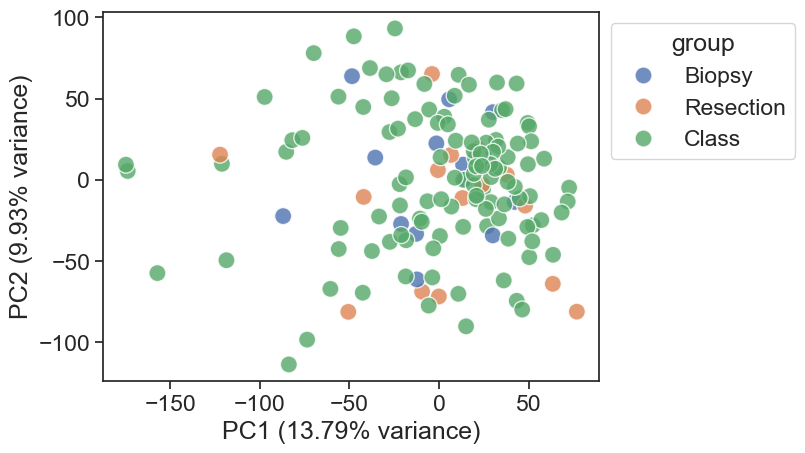

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_4452\3849490012.py:21: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca[df_pca.patient_id != 'nan'], x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


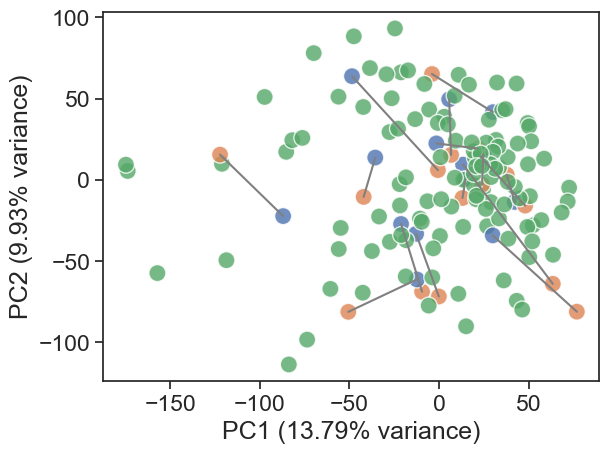

In [29]:
df_pca = pd.DataFrame(projections, columns=['PC1', 'PC2'], index=df_vst.columns)
df_pca['group'] = metadata.Sample_type
df_pca['patient_id'] = metadata['Patient ID'].astype(str)

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order = hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
xlim = g.get_xlim()
ylim = g.get_ylim()
plt.savefig('PCA_classification.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()


# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca[df_pca.patient_id != 'nan'], x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig('PCA_classification_pat.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()
